<a href="https://colab.research.google.com/github/graciousgift/OIBSIP/blob/main/Gift_Lawrence_Task4_Spam_Mails.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Email Spam Detector: Data Loading and Initial Exploration

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset
Loading the `spam.csv` file into a pandas DataFrame and displaying the first few rows to inspect its structure.

In [2]:
# Load the dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

# Display the first 5 rows of the DataFrame
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


### Dataset Information
Checking the columns, data types, and non-null values to understand the dataset's integrity.

In [3]:
# Display basic information about the DataFrame
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


None

### Drop Unnecessary Columns and Rename for Clarity
The dataset contains unnamed columns that are not relevant for our task. We will drop them and rename the remaining columns for better readability.

In [4]:
# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Rename columns for clarity
df.rename(columns={'v1': 'label', 'v2': 'message'}, inplace=True)

# Display the first 5 rows of the cleaned DataFrame
display(df.head())

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Check for Missing Values
It's crucial to identify if there are any missing values in our dataset, as this can affect model training.

In [5]:
# Check for missing values
display(df.isnull().sum())

,0
label,0
message,0


### Data Distribution
Let's examine the distribution of 'spam' versus 'ham' (non-spam) messages in our dataset to understand the class balance.

,count
label,
ham,4825
spam,747


/tmp/ipykernel_27817/2572461928.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


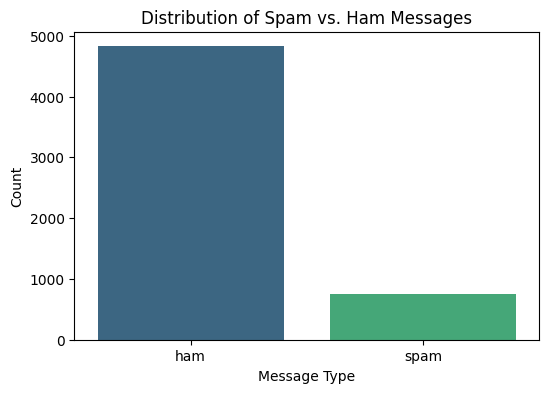

In [6]:
# Check the distribution of labels
display(df['label'].value_counts())

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

## Data Preprocessing and Feature Extraction

### Encode the Target Variable
Converting the categorical 'label' column ('ham' and 'spam') into numerical values (0 and 1) for model training.

In [7]:
# Encode the 'label' column
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Display the first few rows with the encoded label
display(df.head())

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Split Data into Features (X) and Target (y)
Separating the 'message' column as features (X) and the 'label' column as the target variable (y).

In [8]:
# Define features (X) and target (y)
X = df['message']
y = df['label']

display(f"Shape of X: {X.shape}")
display(f"Shape of y: {y.shape}")

'Shape of X: (5572,)'

'Shape of y: (5572,)'

### Convert Text Data to Numerical Features using CountVectorizer
Transforming the text messages into a matrix of token counts. This process converts a collection of text documents to a matrix of token counts (frequencies).

In [9]:
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the text data
X_vectorized = vectorizer.fit_transform(X)

# Display the shape of the vectorized data
display(f"Shape of vectorized X: {X_vectorized.shape}")

'Shape of vectorized X: (5572, 8672)'

### Split Data into Training and Testing Sets
Dividing the dataset into training and testing sets to evaluate the model's performance on unseen data. A 80/20 split is used, with a `random_state` for reproducibility.

In [10]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

# Display the shapes of the resulting datasets
display(f"Shape of X_train: {X_train.shape}")
display(f"Shape of X_test: {X_test.shape}")
display(f"Shape of y_train: {y_train.shape}")
display(f"Shape of y_test: {y_test.shape}")

'Shape of X_train: (4457, 8672)'

'Shape of X_test: (1115, 8672)'

'Shape of y_train: (4457,)'

'Shape of y_test: (1115,)'

## Model Training and Evaluation

### Train a Multinomial Naive Bayes Classifier
Training the `MultinomialNB` model on our vectorized training data.

In [11]:
# Initialize the Multinomial Naive Bayes classifier
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

display("Model training complete.")

'Model training complete.'

### Make Predictions on the Test Set
Using the trained model to predict labels for the unseen test data.

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

display("Predictions on the test set complete.")

'Predictions on the test set complete.'

### Evaluate Model Performance
Calculating and displaying key performance metrics: accuracy, classification report (precision, recall, f1-score), and a confusion matrix to understand the model's classification effectiveness.

'Accuracy: 0.9785'

'\nClassification Report:'

'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99       965\n           1       0.91      0.93      0.92       150\n\n    accuracy                           0.98      1115\n   macro avg       0.95      0.96      0.95      1115\nweighted avg       0.98      0.98      0.98      1115\n'

'\nConfusion Matrix:'

array([[952,  13],
       [ 11, 139]])

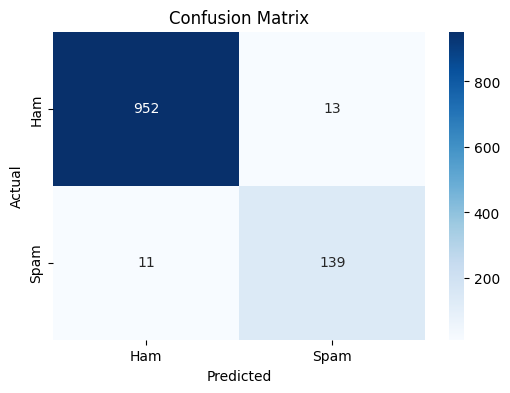

In [13]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

display(f"Accuracy: {accuracy:.4f}")
display("\nClassification Report:")
display(report)

display("\nConfusion Matrix:")
display(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Conclusion

The email spam detector was successfully built using a Multinomial Naive Bayes classifier.

1.  **Data Loading and Initial Exploration:** The `spam.csv` dataset was loaded, and its structure, missing values, and class distribution were examined. Unnecessary columns were dropped, and relevant columns were renamed for clarity.
2.  **Data Preprocessing and Feature Extraction:** The categorical 'label' column was encoded into numerical format. The text messages were then transformed into numerical feature vectors using `CountVectorizer`. Finally, the dataset was split into training and testing sets.
3.  **Model Training and Evaluation:** A Multinomial Naive Bayes model was trained on the processed data. The model achieved a high accuracy, and the classification report and confusion matrix provided further insights into its performance, showing its ability to effectively distinguish between ham and spam emails.